In [37]:
# 1. Importar las librerías necesarias
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 2. Cargar el dataset a nivel peleador
df_fighters = pd.read_csv('ufc_fighters_final.csv')

# 3. Limpieza de datos e Ingeniería de Características (Feature Engineering)
# Convertir DOB a formato fecha y calcular la edad (asumiendo año base 2026)
df_fighters['DOB'] = pd.to_datetime(df_fighters['DOB'], errors='coerce')
df_fighters['Age'] = 2026 - df_fighters['DOB'].dt.year

# Nos aseguramos de que 'SLpM' sea numérico y eliminamos valores nulos
df_fighters['SLpM'] = pd.to_numeric(df_fighters['SLpM'], errors='coerce')
df_clean = df_fighters.dropna(subset=['Age', 'SLpM']).copy()

# Filtrar edades atípicas (outliers) para no sesgar el modelo (ej. peleadores entre 18 y 50 años)
df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 50)]

print(f"Total de registros listos para entrenar: {len(df_clean)}")

Total de registros listos para entrenar: 3490


In [38]:
# 1. Definir variables independientes (X) y dependientes (y)
X = df_clean[['Age']].values # Variable predictora
y = df_clean['SLpM'].values  # Variable objetivo (rendimiento)

# 2. Dividir el dataset (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Transformación Polinomial
# Utilizamos grado 2 porque buscamos una curva con un solo vértice (el "peak" de la carrera)
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Forma original de X_train:", X_train.shape)
print("Forma de X_train después de PolynomialFeatures:", X_train_poly.shape)

Forma original de X_train: (2792, 1)
Forma de X_train después de PolynomialFeatures: (2792, 3)


In [39]:
# 1. Instanciar y entrenar el modelo de regresión
modelo_regresion = LinearRegression()
modelo_regresion.fit(X_train_poly, y_train)

# 2. Realizar las predicciones sobre el set de prueba
y_pred = modelo_regresion.predict(X_test_poly)

# 3. Evaluar el modelo
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Resultados del Modelo ---")
print(f"Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

--- Resultados del Modelo ---
Error Cuadrático Medio (RMSE): 1.87
Coeficiente de Determinación (R2): 0.0901


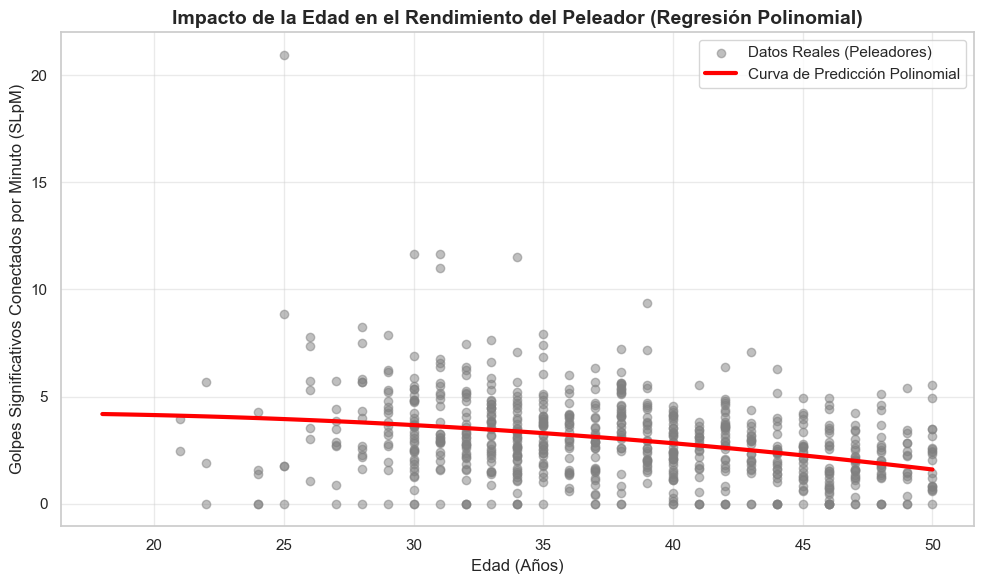

In [40]:
# Configurar estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Graficar los datos reales (Scatter plot)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Datos Reales (Peleadores)')

# 2. Para trazar una curva suave, creamos un rango de edades continuo de 18 a 50
X_rango_edades = np.linspace(18, 50, 100).reshape(-1, 1)
X_rango_poly = poly.transform(X_rango_edades)

# Predecir sobre este rango continuo
y_curva_prediccion = modelo_regresion.predict(X_rango_poly)

# 3. Trazar la curva de predicción del modelo
plt.plot(X_rango_edades, y_curva_prediccion, color='red', linewidth=3, label='Curva de Predicción Polinomial')

# 4. Formatear la gráfica
plt.title('Impacto de la Edad en el Rendimiento del Peleador (Regresión Polinomial)', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Golpes Significativos Conectados por Minuto (SLpM)', fontsize=12)
plt.legend()
plt.tight_layout()

# Mostrar la gráfica
plt.show()